# Latent Masked Transformer Attention Overview

Straightforward demo notebook for the Transformer-style `LatentAttnMasked` attention model.

This version moves beyond the simple single-pass attention setting and focuses on:
- PCA latent structure
- token construction before and after the Transformer stack
- updated token states after multi-layer self-attention
- a short math summary and a final markdown export cell


In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import main
import models.config
import models.eval
import models.lightning_module
import models.loss
import models.latent_attn_masked
import models.conditional_gaussian

importlib.reload(models.loss)
importlib.reload(models.lightning_module)
importlib.reload(models.latent_attn_masked)
importlib.reload(models.conditional_gaussian)
importlib.reload(models.eval)
importlib.reload(models.config)
importlib.reload(main)

from IPython.display import Markdown, display
from main import Sim
from models.config import build_model
from models.loss import get_model_input

RESULTS_ROOT = Path('results/local_results')
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/ext3/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


LatentAttnMasked init | src=SC tgt=FC | k=64 pls=32 | token_embedding_type=learned token_embedding_dim=64 | residual_mode=attention_only residual_gain_init=0.001 | attn_dim=64 value_dim=64 | transformer_layers=2 num_heads=2 | readout_type=mlp readout_hidden_dim=64 | attention_activation=identity | zscore_pca_scores=False | mask_ratio=0.9 visible_fc_context=True | sc_token_dropout=0.0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /scratch/asr655/neuroinformatics/Conn2Conn/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | LatentAttnMasked | 118 K  | train | 0    
1 | loss_fn | MSELoss          | 0      | train | 0    
---------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.
/home/asr655/.local/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=4` in the `DataLoader` to improve performance.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.



Training complete!


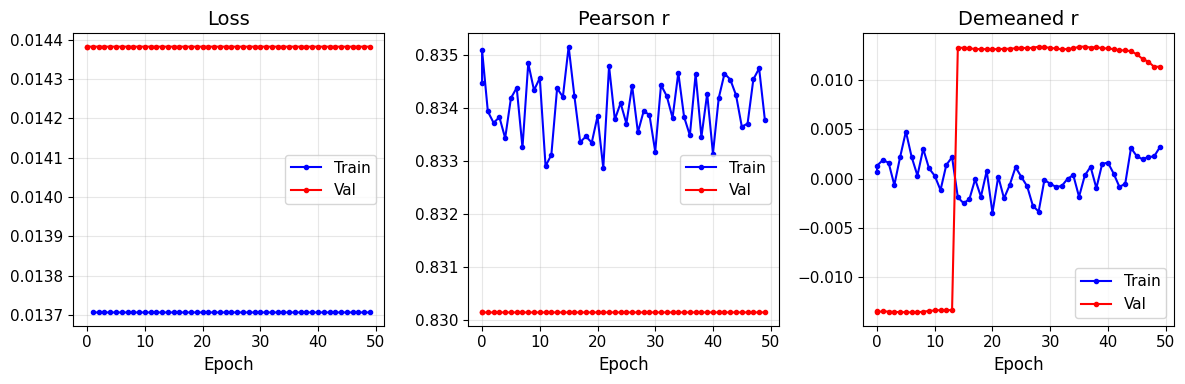

Number of unique demographic categories: 14
Top-1 accuracy: 0.000  (0 of 195 subjects had rank 1) (chance=0.005)
Average rank percentile: 0.529 (chance=0.5)


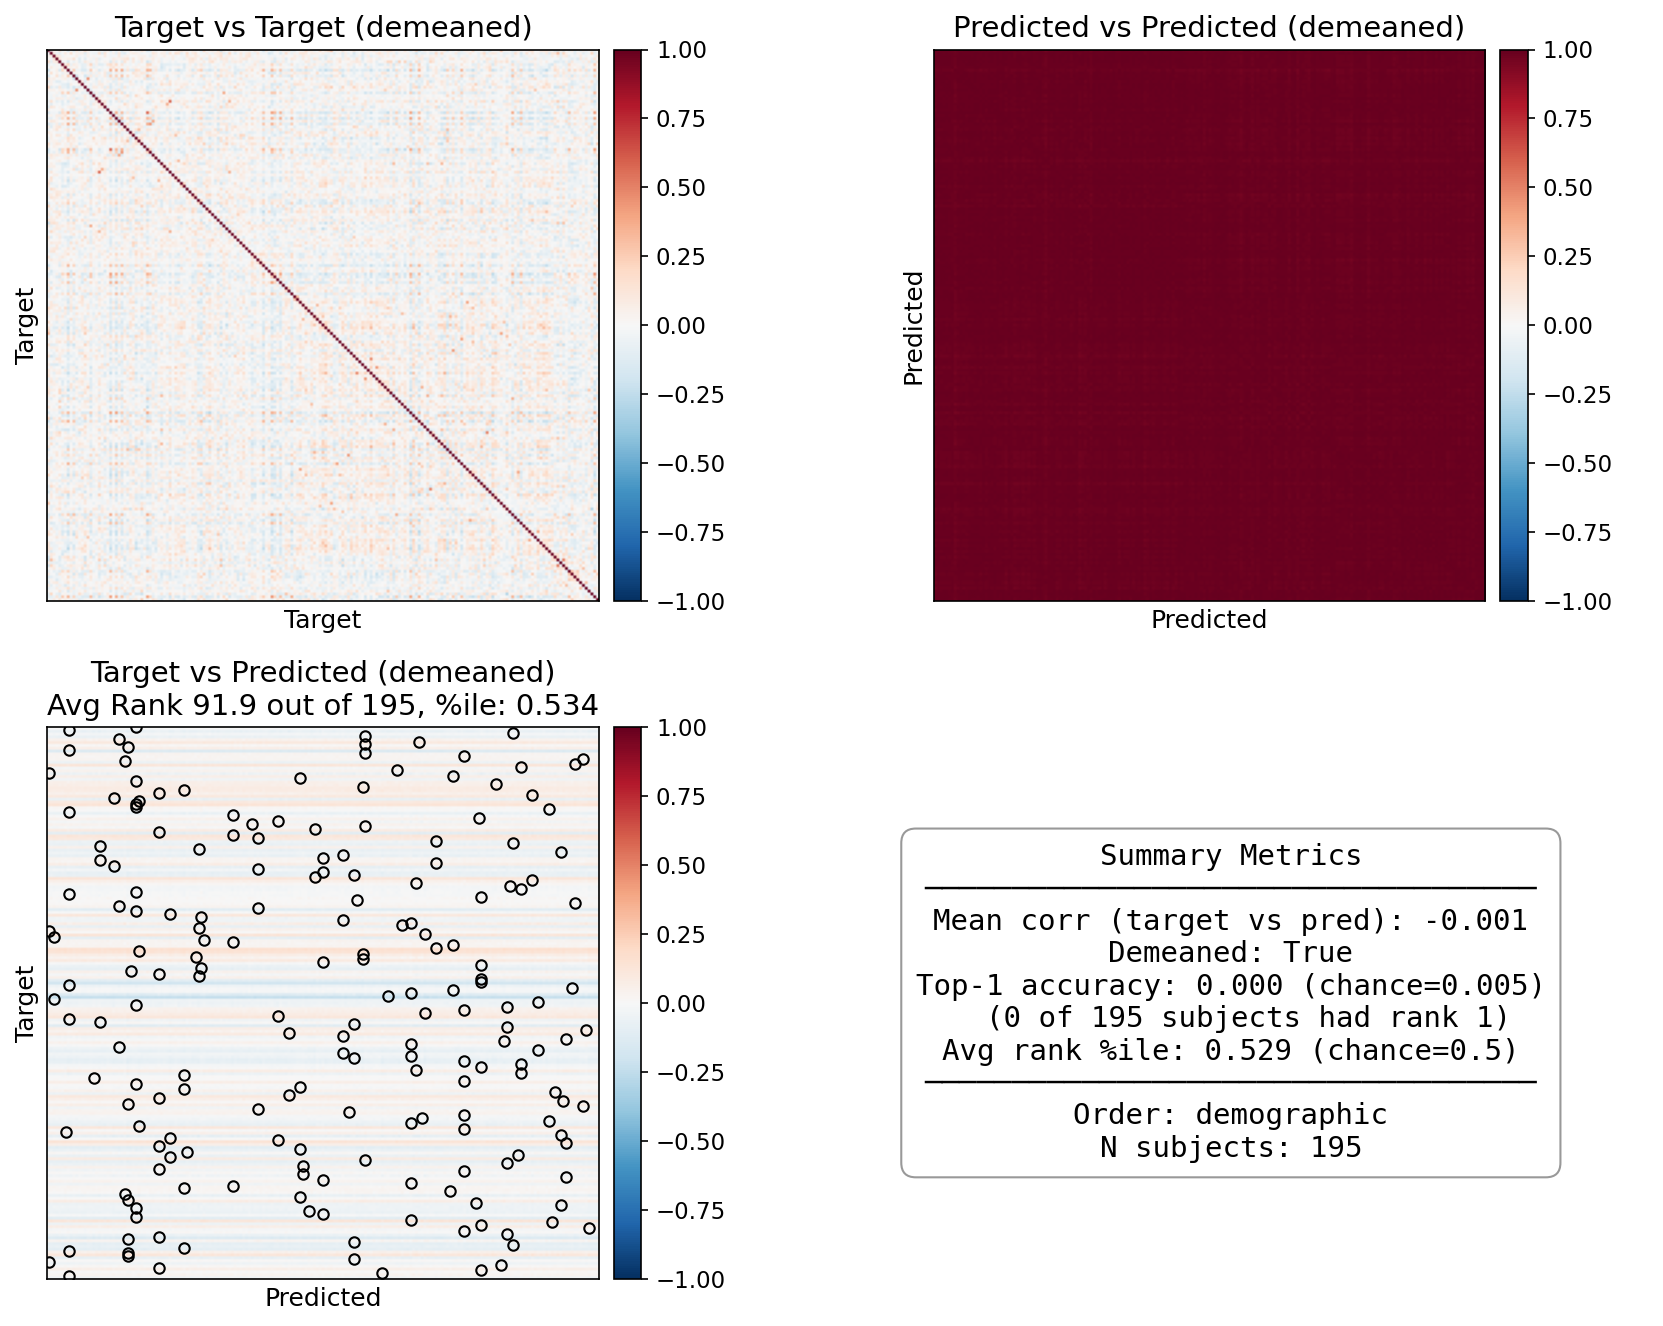

returned noise_preds [[ 0.10335521  0.27345122  0.79338547 ...  0.07845211  0.10779614
   0.35724186]
 [ 0.1919979   0.47149277  0.6724819  ... -0.13729251 -0.09331813
   0.66529665]
 [ 0.3631451   0.63926478  0.88444692 ... -0.01370378  0.1294217
   0.39960487]
 ...
 [-0.08238107  0.82869741  1.07752772 ... -0.06908563 -0.00440757
   0.40327927]
 [ 0.12395491  0.68586381  0.6269891  ... -0.12566293  0.16673286
   0.53747594]
 [ 0.05569953  0.62698837  0.69579952 ... -0.09271121  0.09947315
   0.36341394]]


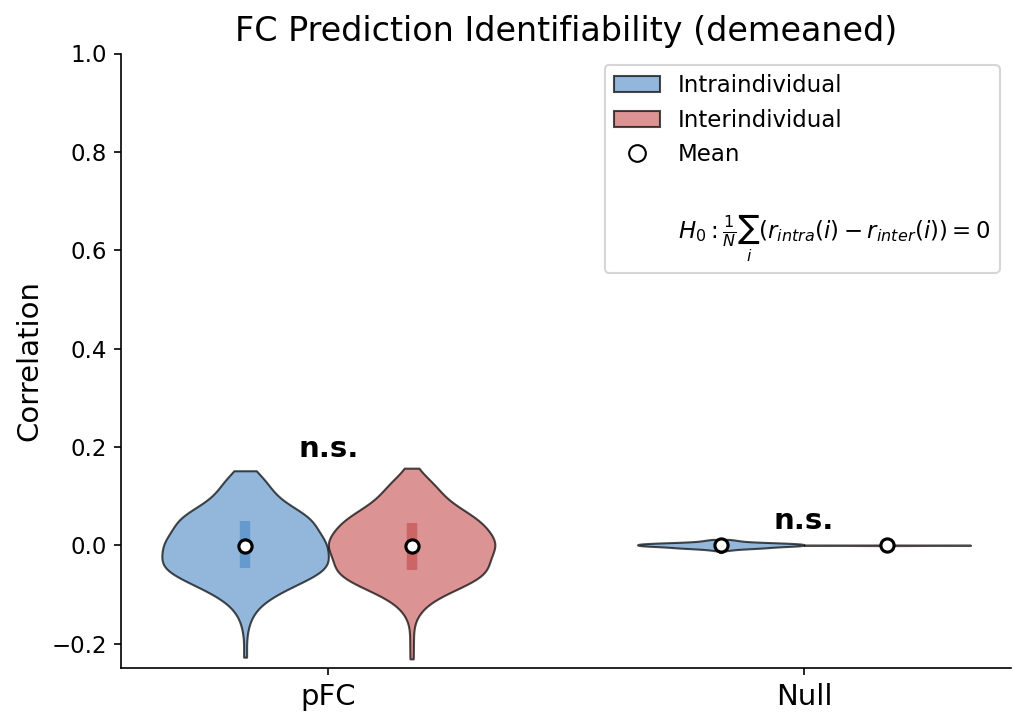


Identifiability Summary:
Condition    r_intra    r_inter    d          t          p            Cohen d   
----------------------------------------------------------------------
pFC          -0.0006    -0.0012    0.0006     1.17       2.45e-01     0.08      
Null         0.0004     -0.0001    0.0005     1.35       1.78e-01     0.10      


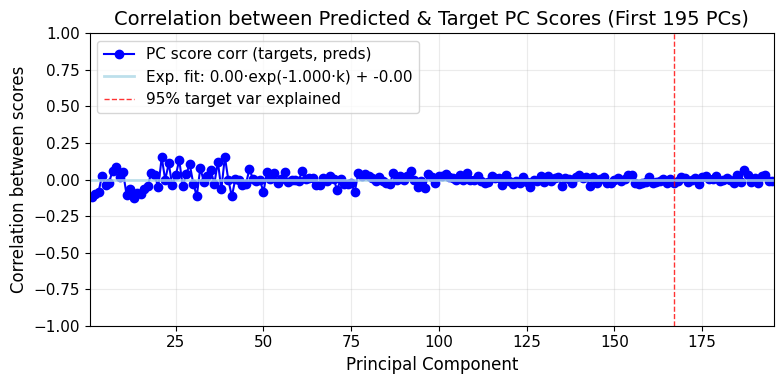

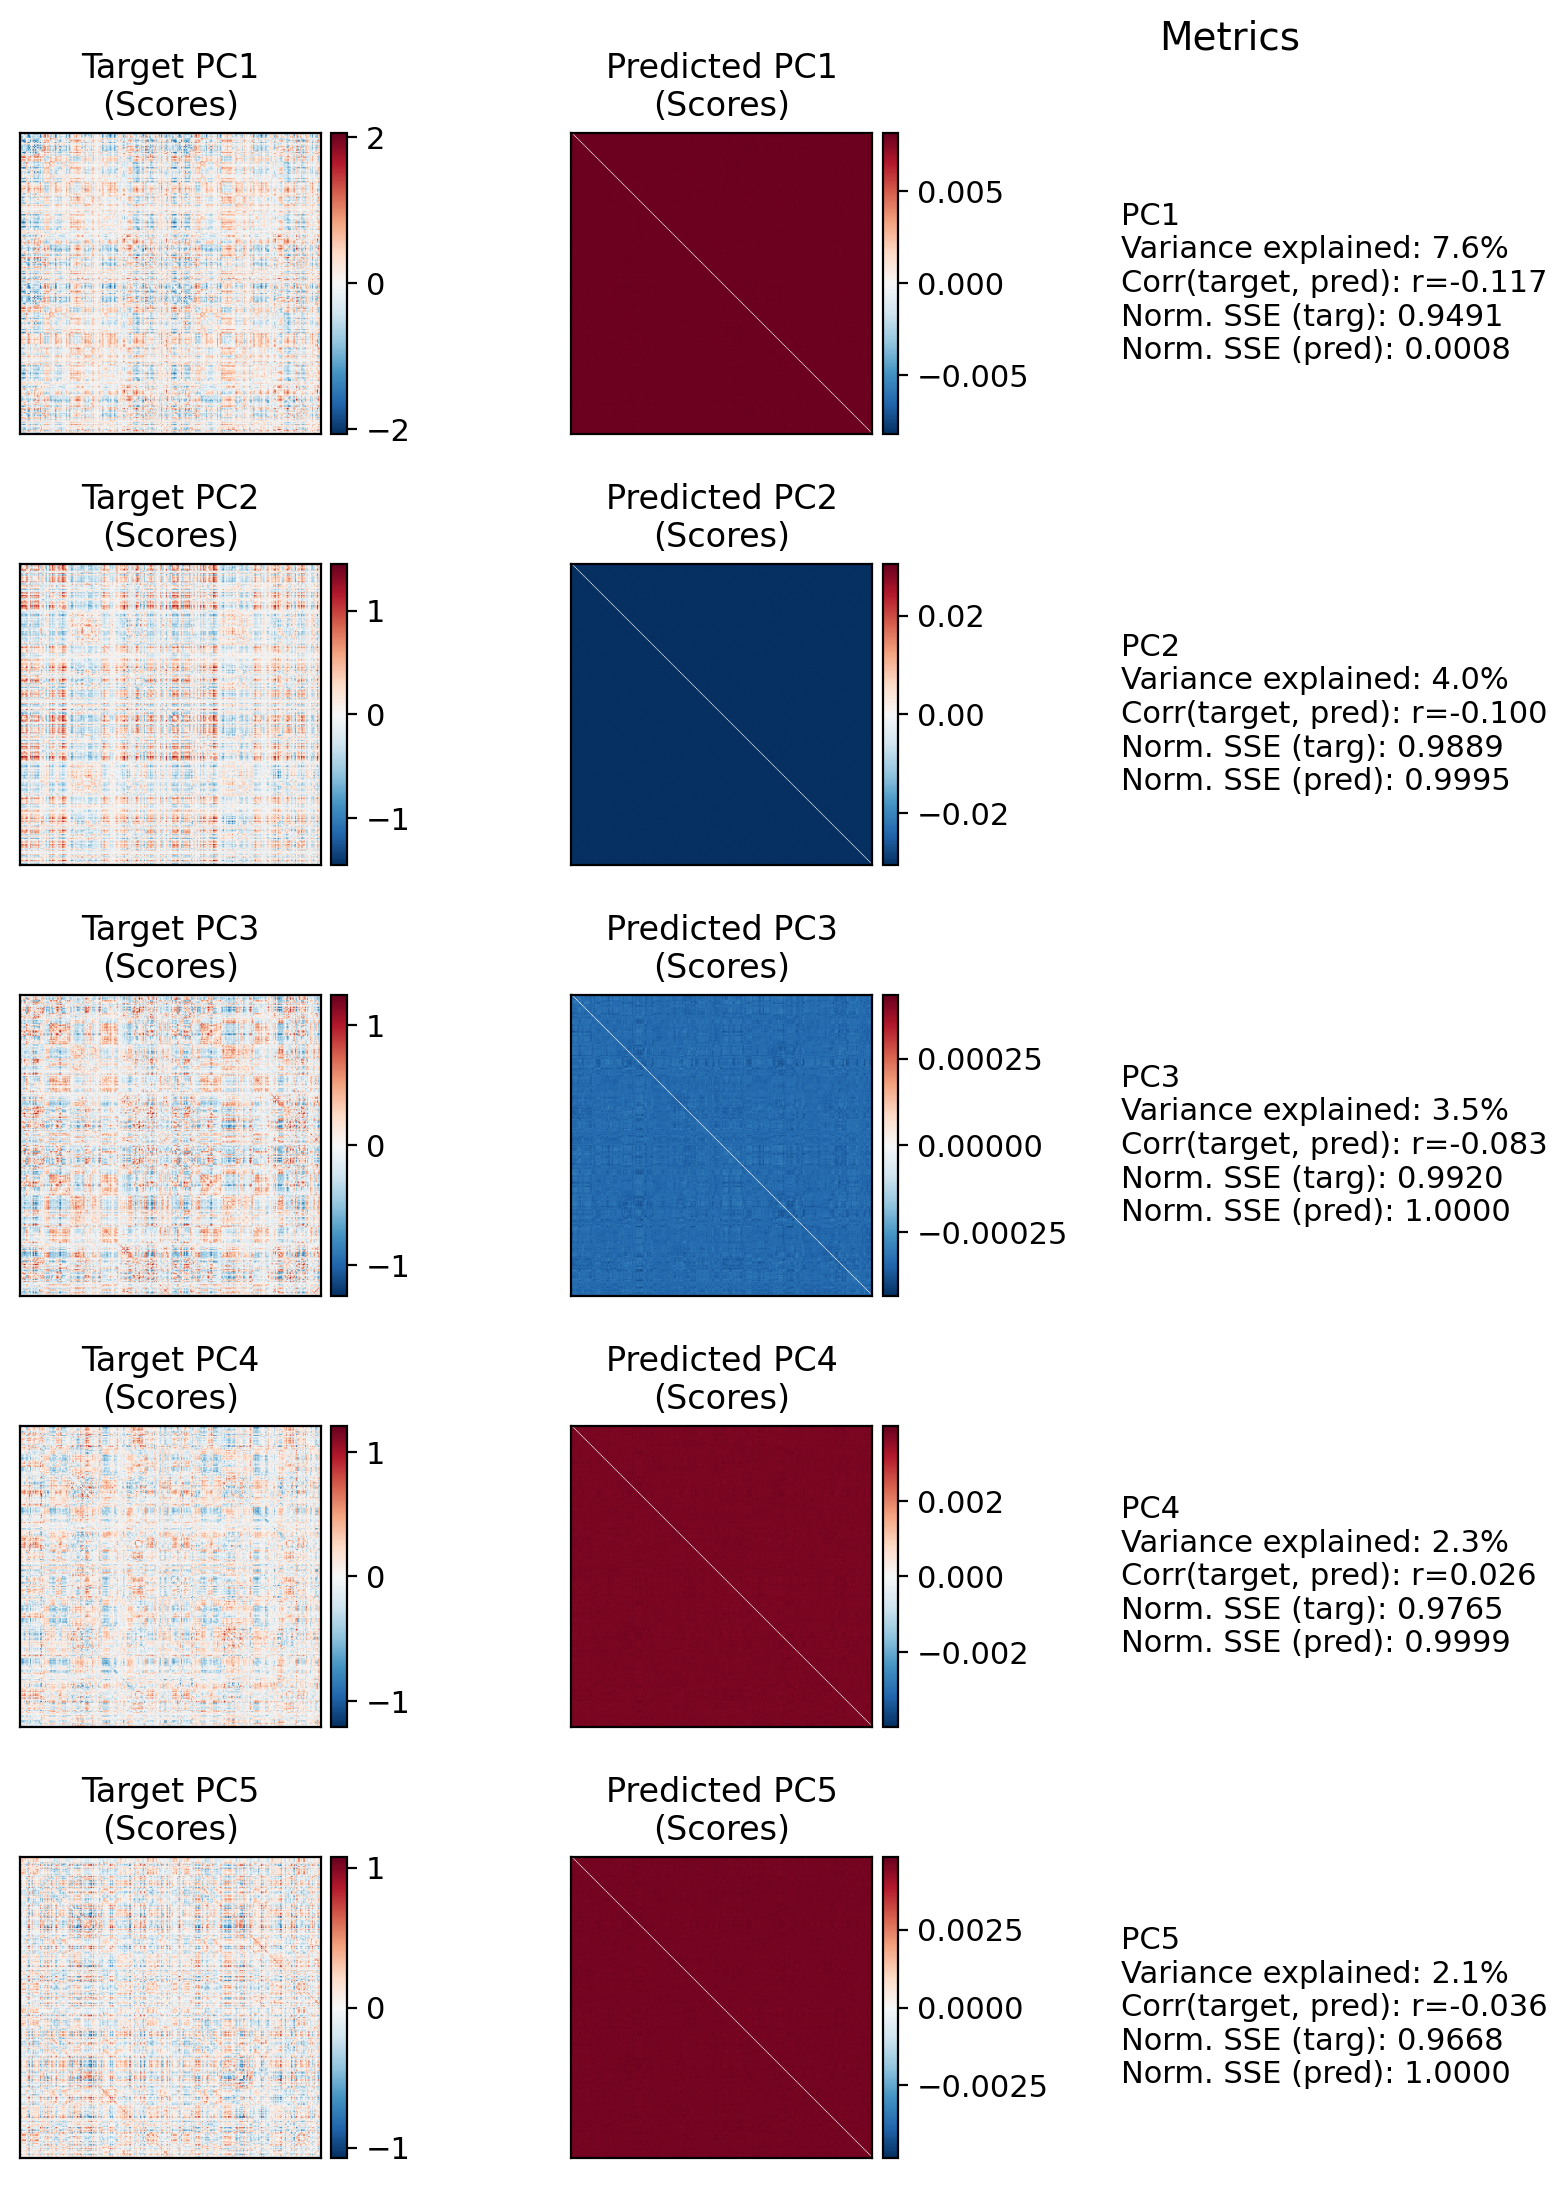

{'mse': np.float32(0.013326822),
 'r2': np.float32(-0.008801958),
 'pearson': np.float32(0.83900136),
 'demeaned_pearson': np.float32(-0.00055833365),
 'avg_rank': np.float64(0.5259960552268245),
 'top1_acc': np.float64(0.0)}

In [3]:
config_override = {
    "model": {
        "n_components_pca": 64,
        "n_components_pls": 32,
        "token_embedding_type": "learned",
        "token_embedding_dim": 64,
        "attn_dim": 64,
        "value_dim": 64,
        "transformer_layers": 2,
        "num_heads": 2,
        "attention_activation": "identity",
        "readout_type": "mlp",
        "readout_hidden_dim": 64,
        "residual_mode": "attention_only",
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.05,
        "reg": 0, # 1e-6,
    },
    "trainer": {
        "max_epochs": 50,
        "batch_size": 128,
        "lr": 1e-4,
        "loss_type": "mse",
    },
}

sim = Sim(
    model_name="LatentAttnMasked",
    config_overrides=config_override,
    source="SC",
    target="FC",
    parcellation="Glasser",
    shuffle_seed=0,
    data_load_mode="precomputed",
)

run_out = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=True,
)

run_out["test_metrics"]["base_metrics"]


LatentAttnMasked init | src=SC tgt=FC | k=256 pls=64 | token_embedding_type=learned token_embedding_dim=128 | residual_mode=attention_only residual_gain_init=1.0 | attn_dim=128 value_dim=128 | transformer_layers=0 num_heads=1 | readout_type=scalar_slot readout_hidden_dim=32 | attention_activation=identity | zscore_pca_scores=False | mask_ratio=0.9 visible_fc_context=True | sc_token_dropout=0.0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | LatentAttnMasked | 98.6 K | train | 0    
1 | loss_fn | MSELoss          | 0      | train | 0    
-------------------------------------------------------------
98.6 K    Trainable params
0         Non-trainable params
98.6 K    Total params
0.394     Total estimated model params size (MB)
9         Modules in

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.



Training complete!


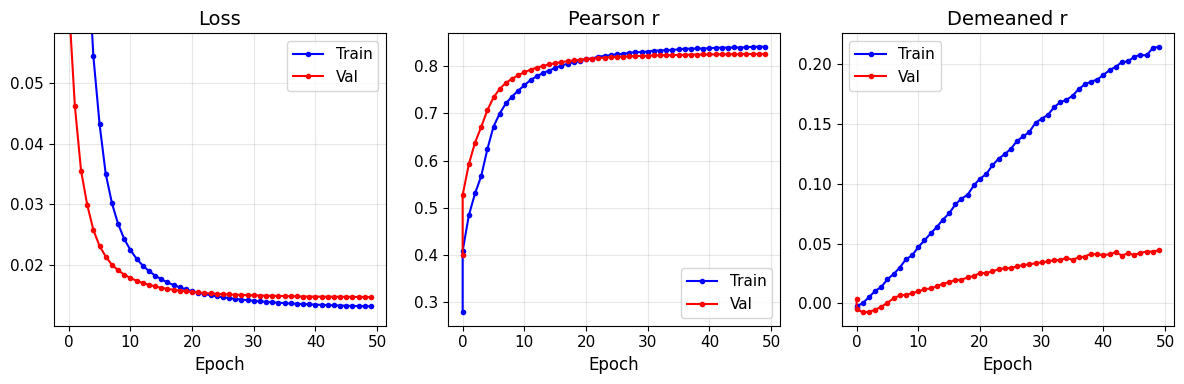

In [15]:
config_override = {
    "model": {
        "n_components_pca": 256,
        "n_components_pls": 64,
        "token_embedding_type": "learned",
        "token_embedding_dim": 128,
        "attn_dim": 128,
        "value_dim": 128,
        "transformer_layers": 0,
        "num_heads": 1,
        "attention_activation": "identity",
        "readout_type": "scalar_slot",
        "readout_hidden_dim": 32,
        "residual_mode": "attention_only",
        "residual_gain_init": 1.0, 
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.0,
        "reg": 0 # 1e-7,
    },
    "trainer": {
        "max_epochs": 50,
        "batch_size": 128,
        "lr": 1e-3,
        "loss_type": "mse",
    },
}

run_out = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=False,
)

#run_out["test_metrics"]["base_metrics"]


LatentAttnMasked init | src=SC tgt=FC | k=256 pls=64 | token_embedding_type=learned token_embedding_dim=128 | residual_mode=attention_only residual_gain_init=1.0 | attn_dim=128 value_dim=128 | transformer_layers=1 num_heads=1 | readout_type=scalar_slot readout_hidden_dim=32 | attention_activation=identity | zscore_pca_scores=False | mask_ratio=0.9 visible_fc_context=True | sc_token_dropout=0.0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | LatentAttnMasked | 266 K  | train | 0    
1 | loss_fn | MSELoss          | 0      | train | 0    
-------------------------------------------------------------
266 K     Trainable params
0         Non-trainable params
266 K     Total params
1.065     Total estimated model params size (MB)
23        Modules in

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



Training complete!


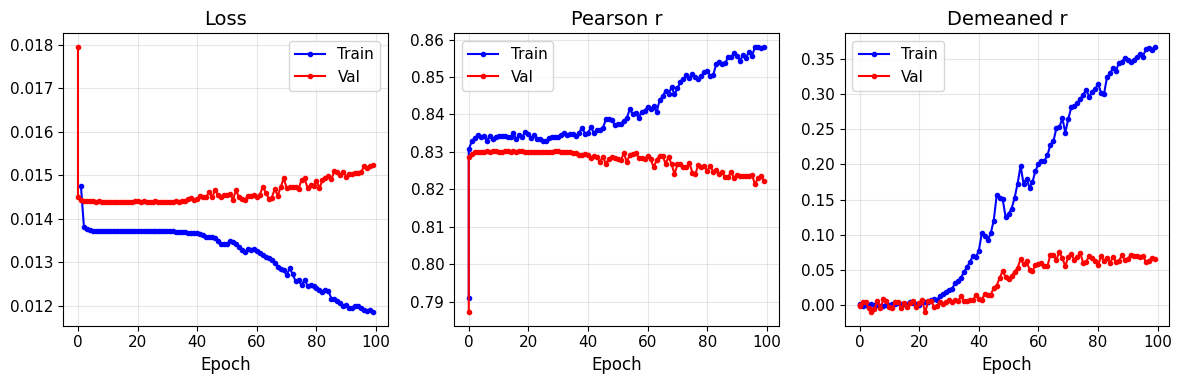

In [18]:
config_override = {
    "model": {
        "n_components_pca": 256,
        "n_components_pls": 64,
        "token_embedding_type": "learned",
        "token_embedding_dim": 128,
        "attn_dim": 128,
        "value_dim": 128,
        "transformer_layers": 1,
        "num_heads": 1,
        "attention_activation": "identity",
        "readout_type": "scalar_slot",
        "readout_hidden_dim": 32,
        "residual_mode": "attention_only",
        "residual_gain_init": 1.0, 
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.0,
        "reg": 0 # 1e-7,
    },
    "trainer": {
        "max_epochs": 100,
        "batch_size": 128,
        "lr": 1e-3,
        "loss_type": "mse",
    },
}

run_out = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=False,
)

#run_out["test_metrics"]["base_metrics"]


LatentAttnMasked init | src=SC tgt=FC | k=256 pls=64 | token_embedding_type=learned token_embedding_dim=128 | residual_mode=attention_only residual_gain_init=1.0 | attn_dim=128 value_dim=128 | transformer_layers=2 num_heads=2 | readout_type=scalar_slot readout_hidden_dim=32 | attention_activation=identity | zscore_pca_scores=False | mask_ratio=0.9 visible_fc_context=True | sc_token_dropout=0.0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | LatentAttnMasked | 466 K  | train | 0    
1 | loss_fn | MSELoss          | 0      | train | 0    
-------------------------------------------------------------
466 K     Trainable params
0         Non-trainable params
466 K     Total params
1.866     Total estimated model params size (MB)
39        Modules in

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.



Training complete!


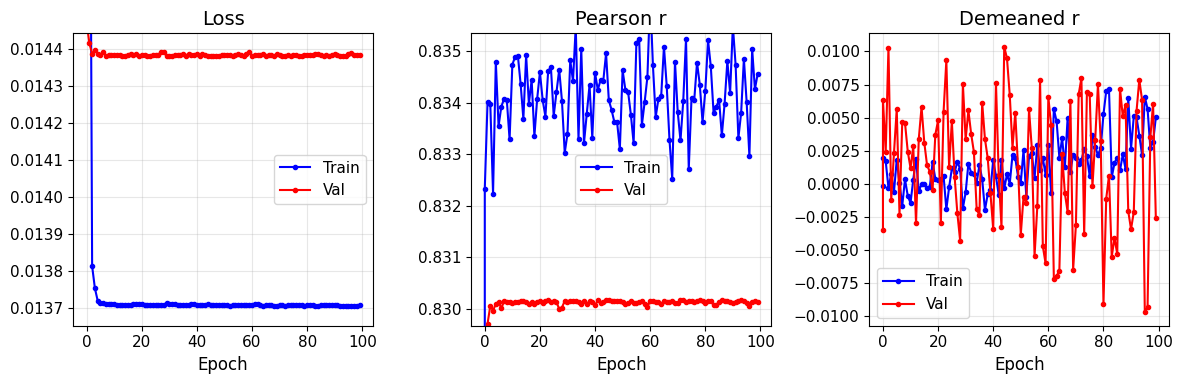

In [20]:
config_override = {
    "model": {
        "n_components_pca": 256,
        "n_components_pls": 64,
        "token_embedding_type": "learned",
        "token_embedding_dim": 128,
        "attn_dim": 128,
        "value_dim": 128,
        "transformer_layers": 2,
        "num_heads": 2,
        "attention_activation": "identity",
        "readout_type": "scalar_slot",
        "readout_hidden_dim": 32,
        "residual_mode": "attention_only",
        "residual_gain_init": 1.0, 
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.0,
        "reg": 0 # 1e-7,
    },
    "trainer": {
        "max_epochs": 100,
        "batch_size": 128,
        "lr": 1e-3,
        "loss_type": "mse",
    },
}

run_out = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=False,
)

#run_out["test_metrics"]["base_metrics"]


LatentAttnMasked init | src=SC tgt=FC | k=256 pls=64 | token_embedding_type=learned token_embedding_dim=128 | residual_mode=attention_only residual_gain_init=1.0 | attn_dim=128 value_dim=128 | transformer_layers=2 num_heads=1 | readout_type=scalar_slot readout_hidden_dim=32 | attention_activation=identity | zscore_pca_scores=False | mask_ratio=0.9 visible_fc_context=True | sc_token_dropout=0.0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | LatentAttnMasked | 466 K  | train | 0    
1 | loss_fn | MSELoss          | 0      | train | 0    
-------------------------------------------------------------
466 K     Trainable params
0         Non-trainable params
466 K     Total params
1.866     Total estimated model params size (MB)
39        Modules in

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.



Training complete!


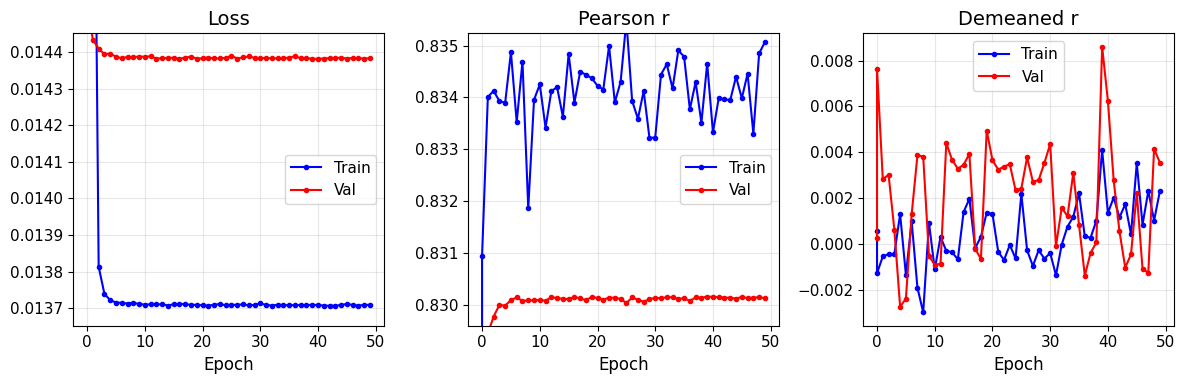

In [17]:
config_override = {
    "model": {
        "n_components_pca": 256,
        "n_components_pls": 64,
        "token_embedding_type": "learned",
        "token_embedding_dim": 128,
        "attn_dim": 128,
        "value_dim": 128,
        "transformer_layers": 2,
        "num_heads": 1,
        "attention_activation": "identity",
        "readout_type": "scalar_slot",
        "readout_hidden_dim": 32,
        "residual_mode": "attention_only",
        "residual_gain_init": 1.0, 
        "mask_ratio": 0.9,
        "train_use_visible_fc_context": True,
        "sc_token_dropout": 0.0,
        "attention_dropout": 0.0,
        "reg": 0 # 1e-7,
    },
    "trainer": {
        "max_epochs": 50,
        "batch_size": 128,
        "lr": 1e-3,
        "loss_type": "mse",
    },
}

run_out = sim._run_learned_single(
    mode="dev",
    save_checkpoint=False,
    config_override=config_override,
    run_eval=False,
)

#run_out["test_metrics"]["base_metrics"]


In [ ]:
run_out["train_result"].plot(style="latent")

In [ ]:
model_trained = run_out["model"]
model_trained.eval()

val_batch = next(iter(sim.val_loader))
x_val = get_model_input(val_batch)
y_val = val_batch["y"]

with torch.no_grad():
    inspect_ex = model_trained.inspect_attention_state(x_val[:1], y=y_val[:1], force_all_masked=True)
    inspect_mean = model_trained.inspect_attention_state(x_val[:16], y=y_val[:16], force_all_masked=True)


In [ ]:
def plot_token_matrix(ax, arr, title):
    arr = arr.detach().cpu().squeeze(0).numpy() if arr.ndim == 3 else arr.detach().cpu().mean(dim=0).numpy()
    bound = np.quantile(np.abs(arr), 0.995) + 1e-8
    im = ax.imshow(arr, aspect="auto", cmap="RdBu_r", vmin=-bound, vmax=bound)
    ax.set_title(title)
    ax.set_xlabel("Token feature")
    ax.set_ylabel("Token index (SC then FC)")
    ax.axhline(model_trained.n_components_pca - 0.5, color="k", linestyle="--", linewidth=1)
    return im

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, tensor, title in [
    (axes[0, 0], inspect_ex["tokens_pre"], "Example tokens before transformer"),
    (axes[0, 1], inspect_ex["tokens_post"], "Example tokens after transformer"),
    (axes[1, 0], inspect_mean["tokens_pre"], "Mean pre-transformer tokens (16 val subjects)"),
    (axes[1, 1], inspect_mean["tokens_post"], "Mean post-transformer tokens (16 val subjects)"),
]:
    im = plot_token_matrix(ax, tensor, title)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
plt.tight_layout()
plt.show()


In [ ]:
example = inspect_ex
base_latent = example["c_target_base"].detach().cpu().squeeze(0).numpy()
delta_latent = example["c_target_delta"].detach().cpu().squeeze(0).numpy()
final_latent = example["c_target_hat"].detach().cpu().squeeze(0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, vec, title, color in [
    (axes[0], base_latent, "Backbone latent base", "#64748b"),
    (axes[1], delta_latent, "Transformer residual delta", "#2563eb"),
    (axes[2], final_latent, "Final latent prediction", "#0f766e"),
]:
    ax.plot(vec, color=color)
    ax.set_title(title)
    ax.set_xlabel("FC latent component")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Math Summary

The Transformer version keeps the same tokenization but replaces the single raw attention pass with a residual-stream stack.

If $T^{(0)}$ is the initial token matrix, then each Transformer block computes

$$
\tilde T^{(\ell)} = T^{(\ell)} + \mathrm{MHA}(\mathrm{LN}(T^{(\ell)}))
$$

$$
T^{(\ell+1)} = \tilde T^{(\ell)} + \mathrm{FFN}(\mathrm{LN}(\tilde T^{(\ell)})).
$$

In this notebook we use two layers and two heads, so the model is

$$
T^{(2)} = \mathrm{TransformerBlock}_2(\mathrm{TransformerBlock}_1(T^{(0)})).
$$

Using the scalar-slot readout, the FC latent correction is taken directly from the first feature channel of the FC token rows after the stack:

$$
\hat c_t = c_{base} + T^{(2)}_{FC,:,0}.
$$


In [ ]:
artifact_dir = RESULTS_ROOT / "latent_masked_transformer_overview"
artifact_dir.mkdir(parents=True, exist_ok=True)
report_base = artifact_dir / "eval_test"

test_eval = run_out["evaluators"]["test"]
report_metrics = test_eval.analyze_results(
    verbose=False,
    filepath=str(report_base),
    output_format="md",
    model_name="LatentAttnMasked_transformer_2layer_2head",
)

print(f"Markdown report saved to: {report_base}.md")
report_metrics["base_metrics"]
